In [110]:
# FieldNBalance is a program that estimates the N balance and provides N fertilizer recommendations for cultivated crops.
# Author: Hamish Brown.
# Copyright (c) 2024 The New Zealand Institute for Plant and Food Research Limited

In [111]:
import os 
import datetime as dt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

CBcolors = {
    'blue':    '#377eb8', 
    'orange':  '#ff7f00',
    'green':   '#4daf4a',
    'pink':    '#f781bf',
    'brown':   '#a65628',
    'purple':  '#984ea3',
    'gray':    '#999999',
    'red':     '#e41a1c',
    'yellow':  '#dede00',
    'black': '#000000'
} 

Path for current Tests

In [112]:
try: 
    if os.environ["GITHUB_WORKSPACE"] != None:
        root = os.environ["GITHUB_WORKSPACE"]
        inPath = os.path.join(root, "TestComponents", "TestSets", "Schedulling", "Outputs")
        outPath = os.path.join(root, "TestGraphs", "Outputs")  
        localDayFirst = False
        localDateFormat = '%m/%d/%Y %H:%M:%S'
except:
    localDayFirst = True
    localDateFormat = '%d/%m/%Y %H:%M:%S %p'
    rootfrags = os.path.abspath('Location.py').split("\\")
    root = ""
    for d in rootfrags:
        if d == "FieldNBalance":
            break
        else:
            root += d + "\\"
    inPath = os.path.join(root,"FieldNBalance","TestComponents", "TestSets", "Schedulling", "Outputs")
    outPath = os.path.join(root,"FieldNBalance","TestGraphs", "Outputs")  

Get names and results from each test

In [113]:
testFiles = []
tests = []
for file in os.listdir(inPath):
    if file.endswith('.csv'):
        testFiles.append(file)
        tests.append(file.replace(".csv",""))

Pack tests up into dataframe for graphing

In [114]:
Alltests =[]
for t in testFiles[:]:  
    testframe = pd.read_csv(os.path.join(inPath, t),index_col=0,dayfirst=localDayFirst,date_format=localDateFormat)  
    Alltests.append(testframe)   

AllData = pd.concat(Alltests,axis=1,keys=tests)
AllData.sort_index(axis=0,inplace=True)
AllData.index = pd.to_datetime(AllData.index)

Make graph

In [115]:
AllData.loc[:,'EarlyReproductive_1'].columns

Index(['SoilMineralN', 'UptakeN', 'ResidueN', 'SoilOMN', 'FertiliserN',
       'CropN', 'ProductN', 'LostN', 'RSWC', 'Drainage', 'Irrigation',
       'Green cover', 'NDemand'],
      dtype='object')

In [116]:
colors = ['purple','purple','green','green','orange','orange','blue','blue','red','red','black','yellow','yellow']
lines = ['-','--','-','--','-','--','-','--','-','--','-','-','--']

In [117]:
Stages = ['Vegetative','LateReproductive','Late']
Splits = ['1','2','3','5']
TestNames = []
for st in Stages:
    for sp in Splits:
        TestNames.append(st+'_'+sp)

In [118]:
AllData

EarlyReproductive_1                              \
                           SoilMineralN UptakeN  ResidueN   SoilOMN   
Date                                                                  
2023-03-25 12:00:00            0.000000     0.0  0.000000  0.841791   
2023-03-26 12:00:00           50.753812     0.0  0.000000  0.753812   
2023-03-27 12:00:00           51.544701     0.0  0.000000  0.790890   
2023-03-28 12:00:00           52.339733     0.0  0.000000  0.795032   
2023-03-29 12:00:00           53.107195     0.0  0.000000  0.767462   
...                                 ...     ...       ...       ...   
2024-10-01 12:00:00           97.959423     0.0  0.017712  0.497572   
2024-10-02 12:00:00           98.437033     0.0  0.016653  0.460957   
2024-10-03 12:00:00           98.903087     0.0  0.016181  0.449873   
2024-10-04 12:00:00           99.349615     0.0  0.015932  0.430597   
2024-10-05 12:00:00           99.799627     0.0  0.016417  0.433595   

                                                                         ...  \
                    FertiliserN CropN ProductN LostN      RSWC Drainage  ...   
Date                                                                     ...   
2023-03-25 12:00:00         0.0   0.0      0.0   0.0  0.900000      0.0  ...   
2023-03-26 12:00:00         0.0   0.0      0.0   0.0  0.866493      0.0  ...   
2023-03-27 12:00:00         0.0   0.0      0.0   0.0  0.846606      0.0  ...   
2023-03-28 12:00:00         0.0   0.0      0.0   0.0  0.820866      0.0  ...   
2023-03-29 12:00:00         0.0   0.0      0.0   0.0  0.797564      0.0  ...   
...                         ...   ...      ...   ...       ...      ...  ...   
2024-10-01 12:00:00         0.0   0.0      0.0   0.0  0.687676      0.0  ...   
2024-10-02 12:00:00         0.0   0.0      0.0   0.0  0.682605      0.0  ...   
2024-10-03 12:00:00         0.0   0.0      0.0   0.0  0.683765      0.0  ...   
2024-10-04 12:00:00         0.0   0.0      0.0   0.0  0.656665      0.0  ...   
2024-10-05 12:00:00         0.0   0.0      0.0   0.0  0.620289      0.0  ...   

                    Vegetative_5                                             \
                         SoilOMN FertiliserN CropN ProductN LostN      RSWC   
Date                                                                          
2023-03-25 12:00:00     0.841791         0.0   0.0      0.0   0.0  0.900000   
2023-03-26 12:00:00     0.753812         0.0   0.0      0.0   0.0  0.866493   
2023-03-27 12:00:00     0.790890         0.0   0.0      0.0   0.0  0.846606   
2023-03-28 12:00:00     0.795032         0.0   0.0      0.0   0.0  0.820866   
2023-03-29 12:00:00     0.767462         0.0   0.0      0.0   0.0  0.797564   
...                          ...         ...   ...      ...   ...       ...   
2024-10-01 12:00:00     0.497572         0.0   0.0      0.0   0.0  0.687676   
2024-10-02 12:00:00     0.460957         0.0   0.0      0.0   0.0  0.682605   
2024-10-03 12:00:00     0.449873         0.0   0.0      0.0   0.0  0.683765   
2024-10-04 12:00:00     0.430597         0.0   0.0      0.0   0.0  0.656665   
2024-10-05 12:00:00     0.433595         0.0   0.0      0.0   0.0  0.620289   

                                                             
                    Drainage Irrigation Green cover NDemand  
Date                                                         
2023-03-25 12:00:00      0.0        0.0    0.003140     0.0  
2023-03-26 12:00:00      0.0        0.0    0.000000     0.0  
2023-03-27 12:00:00      0.0        0.0    0.000000     0.0  
2023-03-28 12:00:00      0.0        0.0    0.000000     0.0  
2023-03-29 12:00:00      0.0        0.0    0.000000     0.0  
...                      ...        ...         ...     ...  
2024-10-01 12:00:00      0.0        0.0    0.999901     0.0  
2024-10-02 12:00:00      0.0        0.0    0.999911     0.0  
2024-10-03 12:00:00      0.0        0.0    0.999919     0.0  
2024-10-04 12:00:00      0.0        0.0    0.999926  

C:\Users\Cflhxb\AppData\Local\Temp\ipykernel_23192\1388820315.py:32: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  Graph.tight_layout(pad=1.5)


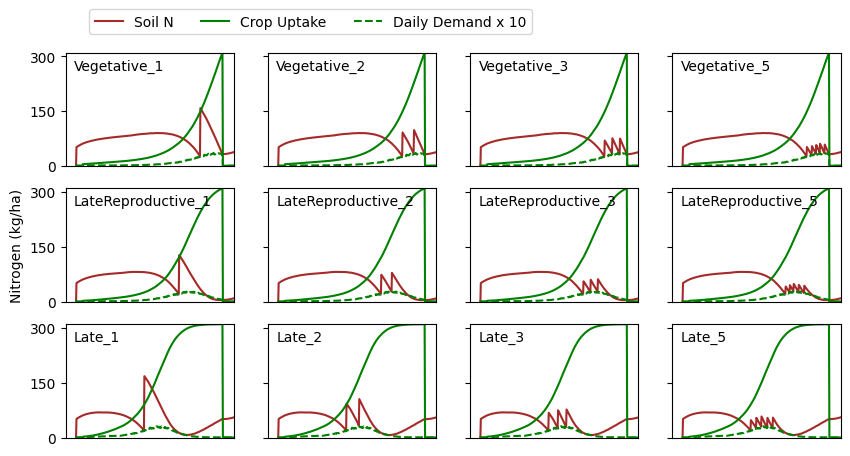

In [119]:
Graph = plt.figure(figsize=(10,5))

pos = 1
for t in TestNames:
    ax = Graph.add_subplot(3,4,pos)
    plt.plot(AllData.loc[:,(t,'SoilMineralN')],color = 'brown',label = 'Soil N')
    #plt.plot(AllData.loc[:,(t,'FertiliserN')],label = 'Fertiliser')
    #plt.plot(AllData.loc[:,(t,'CropN')],label = 'CropN')
    plt.plot(AllData.loc[:,(t,'NDemand')],color = 'green',label = 'Crop Uptake')
    #plt.plot(AllData.loc[:,(t,'LostN')],label = 'LostN')
    #plt.plot(AllData.loc[:,(t,'SoilOMN')].cumsum(),label = 'SoilOMN')
    #plt.plot(AllData.loc[:,(t,'ResidueN')].cumsum(),label = 'ResidueN')
    plt.plot(AllData.loc[:,(t,'UptakeN')]*10, '--',color = 'green',label = 'Daily Demand x 10')
    
    plt.text(0.05,0.85,t,fontsize = 10,transform=ax.transAxes)
    if pos == 1:
        plt.legend(ncols=3,loc='lower left', bbox_to_anchor=(0.1, 1.1))
        
    if pos in [1,5,9]:
        ax.set_yticks(ticks = [0,150,300],labels = [0,150,300])
        if pos ==5:
            plt.ylabel('Nitrogen (kg/ha)')
    else:
        ax.set_yticks(ticks = [0,150,300],labels = ["","",""])
    
    ax.set_xticks(ticks = [])
                                   
    ax.set_xlim(np.datetime64("2023-03-01"), np.datetime64("2024-04-01"))
    pos +=1
    plt.ylim(0,310)    
# plt.text(0.05,0.95,"Crop Cover with different Establish and Harvest Stages",fontsize = 16,transform=ax.transAxes)
Graph.tight_layout(pad=1.5)

# plt.savefig(os.path.join(outPath,'3-CropStage_Cover.png'))

IndexError: list index out of range

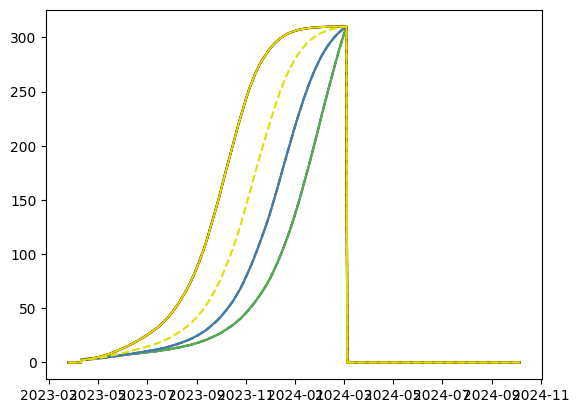

In [120]:
Graph = plt.figure()
ax = Graph.add_subplot(1,1,1)
pos = 0
for t in tests:
    plt.plot(AllData.loc[:,(t,'CropN')],lines[pos],color=CBcolors[colors[pos]],label = t)
    pos +=1
plt.legend(loc=(1.01,0.01))
plt.ylabel('Cum CropNUptake (kg/ha)')
plt.xticks(rotation=60)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%#d-%b'))
plt.text(0.05,0.95,"NUptake With different establish and harvest stages",fontsize = 16,transform=ax.transAxes)
Graph.tight_layout(pad=1.5)
plt.savefig(os.path.join(outPath,'3-CropStage_NUptake.png'))